<a href="https://colab.research.google.com/github/Prudhvi0650/myfirstrepo/blob/main/Predicting_Urban_Bike_Share_Demand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Let's know about the dataset and our objective in building a predictive model

Goal: Our goal is to predict the total number of bike rentals in a given hour. Looking at the dataset description on your screen, the target variable we want to predict is cnt (count of total rental bikes

This project teaches you how to work with time-series data. You'll analyze how factors like temperature, humidity, and wind speed have a linear relationship with rider demand. You can also get creative by engineering features like "feels-like temperature" or a "good weather score."

[Information extracted from Kaggle]

Bike sharing systems are a new generation of traditional bike rentals where the whole process from membership, rental and return back has become automatic. Through these systems, user is able to easily rent a bike from a particular position and return back to another position. Currently, there are about over 500 bike-sharing programs around the world which are composed of over 500 thousands bicycles. Today, there exists great interest in these systems due to their important role in traffic, environmental and health issues.

Apart from interesting real-world applications of bike sharing systems, the characteristics of data being generated by these systems make them attractive for the research. Opposed to other transport services such as bus or subway, the duration of travel, departure and arrival position is explicitly recorded in these systems. This feature turns bike sharing system into a virtual sensor network that can be used for sensing mobility in the city. Hence, it is expected that most of important events in the city could be detected via monitoring these data.

This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system in Washington, DC with the corresponding weather and seasonal information.

Content
Both hour.csv and day.csv have the following fields, except hr which is not available in day.csv

instant: Record index
dteday: Date
season: Season (1:springer, 2:summer, 3:fall, 4:winter)
yr: Year (0: 2011, 1:2012)
mnth: Month (1 to 12)
hr: Hour (0 to 23)
holiday: weather day is holiday or not (extracted from Holiday Schedule)
weekday: Day of the week
workingday: If day is neither weekend nor holiday is 1, otherwise is 0.
weathersit: (extracted from Freemeteo)
1: Clear, Few clouds, Partly cloudy, Partly cloudy
2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
temp: Normalized temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 (only in hourly scale)
atemp: Normalized feeling temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-16, t_max=+50 (only in hourly scale)
hum: Normalized humidity. The values are divided to 100 (max)
windspeed: Normalized wind speed. The values are divided to 67 (max)
casual: count of casual users
registered: count of registered users
cnt: count of total rental bikes including both casual and registered


##Predicting Urban Bike-Share Demand

In [1]:
import pandas as pd
import numpy as np
import keras
import plotly.express as px

Load the Dataset

In [2]:
bike_rental_dataset = pd.read_csv("day.csv")

In [3]:
print(bike_rental_dataset.shape)
bike_rental_dataset.head()

(731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Let's View the Statistics of the dataset to understand the data better

In [4]:
bike_rental_dataset.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2012-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,NaN,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,NaN,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,NaN,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,NaN,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000


In [5]:
missing_values_count = bike_rental_dataset.isnull().sum().sum()
print("Are any features missing data? 				Answer:", "No" if missing_values_count == 0 else "Yes")

Are any features missing data? 				Answer: No


In [6]:
bike_rental_dataset.corr(numeric_only=True)

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
instant,1.000000,0.412224,0.866025,0.496702,0.016145,-0.000016,-0.004337,-0.021477,0.150580,0.152638,0.016375,-0.112620,0.275255,0.659623,0.628830
season,0.412224,1.000000,-0.001844,0.831440,-0.010537,-0.003080,0.012485,0.019211,0.334315,0.342876,0.205445,-0.229046,0.210399,0.411623,0.406100
yr,0.866025,-0.001844,1.000000,-0.001792,0.007954,-0.005461,-0.002013,-0.048727,0.047604,0.046106,-0.110651,-0.011817,0.248546,0.594248,0.566710
mnth,0.496702,0.831440,-0.001792,1.000000,0.019191,0.009509,-0.005901,0.043528,0.220205,0.227459,0.222204,-0.207502,0.123006,0.293488,0.279977
holiday,0.016145,-0.010537,0.007954,0.019191,1.000000,-0.101960,-0.253023,-0.034627,-0.028556,-0.032507,-0.015937,0.006292,0.054274,-0.108745,-0.068348
weekday,-0.000016,-0.003080,-0.005461,0.009509,-0.101960,1.000000,0.035790,0.031087,-0.000170,-0.007537,-0.052232,0.014282,0.059923,0.057367,0.067443
workingday,-0.004337,0.012485,-0.002013,-0.005901,-0.253023,0.035790,1.000000,0.061200,0.052660,0.052182,0.024327,-0.018796,-0.518044,0.303907,0.061156
weathersit,-0.021477,0.019211,-0.048727,0.043528,-0.034627,0.031087,0.061200,1.000000,-0.120602,-0.121583,0.591045,0.039511,-0.247353,-0.260388,-0.297391
temp,0.150580,0.334315,0.047604,0.220205,-0.028556,-0.000170,0.052660,-0.120602,1.000000,0.991702,0.126963,-0.157944,0.543285,0.540012,0.627494
atemp,0.152638,0.342876,0.046106,0.227459,-0.032507,-0.007537,0.052182,-0.121583,0.991702,1.000000,0.139988,-0.183643,0.543864,0.544192,0.631066


In [7]:
px.imshow(bike_rental_dataset.corr(numeric_only=True))

In [10]:
px.scatter_matrix(bike_rental_dataset, width=1200, height=1200)

goal is to build a predictive model for the cnt (bike rental count), here is a clear roadmap to proceed, moving from data preparation to training a model that can handle these complexities.

Step 1: Feature Engineering
First, you need to convert your raw data into a format that a machine learning model can understand. This involves handling dates and categorical variables.

1. Process the Date Column
The dteday column is currently a string. You can extract valuable information from it.

In [11]:
# Convert 'dteday' to a datetime object
bike_rental_dataset['dteday'] = pd.to_datetime(bike_rental_dataset['dteday'])

# Extract features like month and weekday (though you already have them)
# This is a good practice to know
bike_rental_dataset['month'] = bike_rental_dataset['dteday'].dt.month
bike_rental_dataset['day_of_week'] = bike_rental_dataset['dteday'].dt.weekday

print("Dataset with new date features:")
bike_rental_dataset.head()

Dataset with new date features:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,month,day_of_week
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,1,5
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,1,6
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,1,0
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,1,1
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,1,2


2. Convert Categorical Features to Numerical
Models need numbers, not text or categories. The best way to handle nominal categories (where there is no inherent order) like season, weekday, and weathersit is through one-hot encoding. This creates new binary (0 or 1) columns for each category.

In [13]:
# Select the categorical columns to encode
categorical_features = ['season', 'mnth', 'weekday', 'weathersit']

# Apply one-hot encoding
bike_rental_dataset = pd.get_dummies(bike_rental_dataset, columns=categorical_features, drop_first=True)

print("Dataset after one-hot encoding:")
bike_rental_dataset.head()

Dataset after one-hot encoding:


,instant,dteday,yr,holiday,workingday,temp,atemp,hum,windspeed,casual,...,mnth_11,mnth_12,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_2,weathersit_3
0,1,2011-01-01,0,0,0,0.344167,0.363625,0.805833,0.160446,331,...,False,False,False,False,False,False,False,True,True,False
1,2,2011-01-02,0,0,0,0.363478,0.353739,0.696087,0.248539,131,...,False,False,False,False,False,False,False,False,True,False
2,3,2011-01-03,0,0,1,0.196364,0.189405,0.437273,0.248309,120,...,False,False,True,False,False,False,False,False,False,False
3,4,2011-01-04,0,0,1,0.200000,0.212122,0.590435,0.160296,108,...,False,False,False,True,False,False,False,False,False,False
4,5,2011-01-05,0,0,1,0.226957,0.229270,0.436957,0.186900,82,...,False,False,False,False,True,False,False,False,False,False


Now, you'll select your final features (X) and the target variable (y).

1. Drop Unnecessary Columns
You should remove columns that are not useful for prediction or would cause data leakage.

instant: It's just a row number.

dteday: You've already extracted the useful information from it.

casual and registered: Since casual + registered = cnt, including them would be giving the model the answer. This is called data leakage.


In [14]:
# Define the target variable
y = bike_rental_dataset['cnt']

# Define the features, dropping the target and unnecessary columns
X = bike_rental_dataset.drop(columns=['cnt', 'instant', 'dteday', 'casual', 'registered'])

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully split and scaled!")

Data successfully split and scaled!


Structuring your code into create_model and train_model functions is a very common and effective practice in machine learning because it makes your experiments much more organized.

You have already done all the necessary data preparation in the previous steps. We can easily adapt the Keras code we've already written to fit that example's structure.

Here’s how you can do it for your bike rental dataset:

Step 1: Define the create_model function
This function will build the architecture of your neural network and compile it. We can even add a parameter to decide how many layers to create.

In [27]:
def create_model(learning_rate, input_shape):
  """Creates and compiles a Keras model with Dropout."""
  model = keras.Sequential([
      keras.layers.Dense(units=128, activation='relu', input_shape=input_shape),
      keras.layers.Dropout(0.2),  # Add a dropout layer
      keras.layers.Dense(units=64, activation='relu'),
      keras.layers.Dropout(0.2),  # Add another dropout layer
      keras.layers.Dense(units=1)
  ])

  model.compile(
      optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
      loss="mean_absolute_error"
  )
  return model

Step 2: Define the train_model function
This function will take the compiled model and your data, then run the training process using model.fit().

In [28]:
# You'll need to import this at the top of your notebook
from keras.callbacks import EarlyStopping

def train_model(model, x_train, y_train, x_val, y_val, epochs, batch_size):
  """Trains the model by feeding it data with early stopping."""

  # Stop training when validation loss hasn't improved in 5 epochs
  early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

  history = model.fit(
      x_train,
      y_train,
      epochs=epochs,
      batch_size=batch_size,
      validation_data=(x_val, y_val),
      callbacks=[early_stopping],  # Add the callback here
      verbose=1
  )
  return history

Step 3: Put it all together
Now you can use these functions to run your experiment cleanly.

In [29]:
# --- Define Hyperparameters ---
learning_rate = 0.01
epochs = 50
batch_size = 32
input_shape = [X_train_scaled.shape[1]]

# --- Run the Experiment ---

# 1. Create the model using your function
my_model = create_model(learning_rate, input_shape)

# 2. Train the model using your function
history = train_model(my_model, X_train_scaled, y_train, X_test_scaled, y_test, epochs, batch_size)

# 3. Evaluate the final model
print("\nEvaluating the trained model on the test set...")
loss = my_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Final Mean Absolute Error on test data: {loss:.2f}")

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4538.3330 - val_loss: 4140.3477
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4330.9204 - val_loss: 3254.8193
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3068.6367 - val_loss: 1504.1365
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1375.3989 - val_loss: 974.1795
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 890.7637 - val_loss: 749.2900
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 803.7922 - val_loss: 648.2746
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 796.0497 - val_loss: 596.1490
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 749.2180 - val_loss: 688.9003
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 733.2968 - val_loss: 570.4839
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 770.8428 - val_loss: 609.1762
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 736.6421 - val_loss: 575.4447
Epoch 12/50
19/19 ━━━━

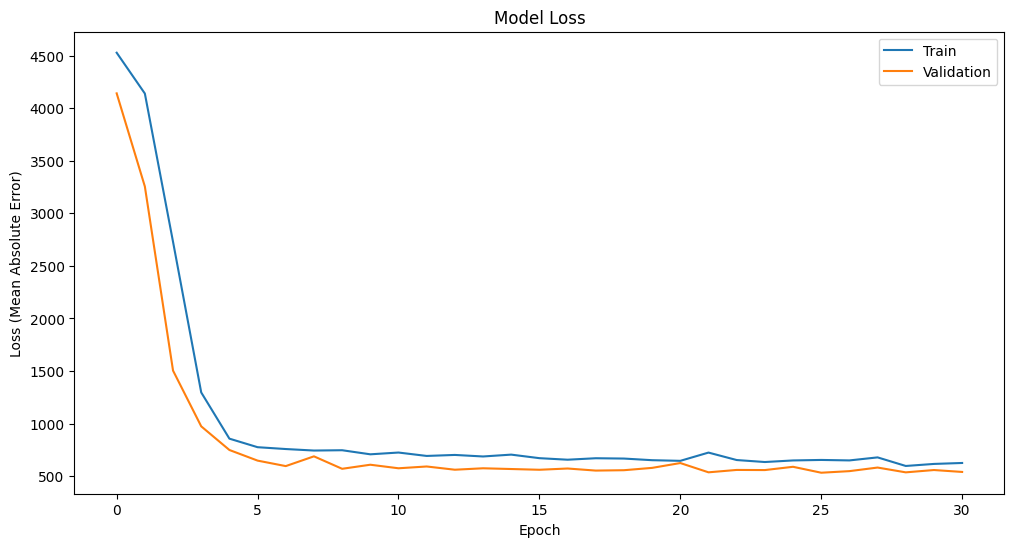

In [31]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss (Mean Absolute Error)')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

In [32]:
# Get the model's predictions
predictions = my_model.predict(X_test_scaled)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [33]:
# Create a new DataFrame for comparison
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': predictions.flatten()})

# Display the first 10 predictions
print("Comparing the first 10 actual values and predictions:")
print(comparison_df.head(10))

Comparing the first 10 actual values and predictions:
     Actual    Predicted
703    6606  5420.693848
33     1550  1500.613892
300    3747  3358.872559
456    6041  4714.339844
633    7538  6697.349121
557    7264  6586.862305
39     1605  1391.272583
356    2209  2277.604004
559    7499  6488.997559
514    5743  6198.971680


In [34]:
# Create a scatter plot
fig = px.scatter(comparison_df, x='Actual', y='Predicted',
                 title='Actual vs. Predicted Bike Rentals',
                 labels={'Actual': 'Actual Count', 'Predicted': 'Predicted Count'})

# Add a line for perfect predictions (y=x)
fig.add_shape(type='line',
              x0=0, y0=0,
              x1=comparison_df['Actual'].max(),
              y1=comparison_df['Actual'].max(),
              line=dict(color='red', dash='dash'))

fig.show()